In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.listdir('/content/drive/MyDrive/ADA')


['Cópia de Aula 1 | Elas+Tech Dados ',
 'playlists_tracks.csv',
 'genres_artists.csv',
 '_winequality_red.csv']

In [ ]:
# Lendo o arquivo CSV da pasta ADA no Google Drive
winequality = pd.read_csv('/content/drive/MyDrive/ADA/_winequality_red.csv')

In [ ]:
# Exibindo as primeiras linhas
winequality.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,76,11.0,34.0,9.978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,98,25.0,67.0,9.968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,92,15.0,54.0,997,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,75,17.0,60.0,998,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,76,11.0,34.0,9.978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,75,13.0,40.0,9.978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,69,15.0,59.0,9.964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,65,15.0,21.0,9.946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,73,9.0,18.0,9.968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,71,17.0,102.0,9.978,3.35,0.80,10.5,5


In [ ]:
# Verificando o tamanho da base de dados (quantidade de linhas e colunas) e o tipo das variáveis.
winequality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   object 
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   object 
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   object 
 11  quality               1599 non-null   int64  
dtypes: float64(8), int64(1), object(3)
memory usage: 150.0+ KB


In [ ]:
winequality.shape

(1599, 12)

In [ ]:
winequality.isna().sum() #mostra quantos campos nulos tem por coluna.

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


# Contextualização
Vamos ler o arquivo csv winequality-red.csv,

construindo um Data Frame do pandas.

Queremos responder:

O que representam os dados nas colunas

Quantas linhas há no dataset?

Quantas colunas há no dataset?

Quais os tipos de dados em cada coluna?

Há dados nulos (null, missing) na base?

Para começar, fomos falar com a area de negócio para entender o que os dados que nos passaram representam, essas são as informações que eles nos trouxeram

Medidas de 11 variáveis físico-químicas que caracterizam cada amostra (as



features do problema):


- 1 - fixed acidity - medida da acidez devido à presença de ácidos orgânicos de baixa volatilidade (ácido málico, lático, tartárico ou cítrico) no vinho; - 2 - volatile acidity - medida da acidez devido a ácidos de baixo peso molecular (sobretudo ácido acético) presentes no vinho, que são responsáveis pelo aroma e gosto de vinagre; - 3 - citric acid - medida de ácido cítrico no vinho; - 4 - residual sugar - medida de açúcar residual presente no vinho, com origem nos resíduos de açúcar da uva que permanecem no vinho após o fim da fermentação; - 5 - chlorides - medida de cloretos (íons de cloro) no vinho; - 6 - free sulfur dioxide - medida de dióxido de enxofre livre (isto é, que não está ligado a outras moléculas) no vinho; - 7 - total sulfur dioxide - medida de dióxido de enxofre total (livre + porção ligada a outras moléculas) no vinho; - 8 - density - medida da densidade do vinho; - 9 - pH - medida do pH do vinho; - 10 - sulphates - medida de sulfatos (íons SO₄²⁻) no vinho; - 11 - alcohol - medida da graduação alcoólica do vinho. - 12 - quality - score numérico de qualidade (de 0 a 10), produzido com base em dados sensoriais.

Daqui já podemos tentar formular um problema. Será que conseguimos tentar descrever a qualidade do vinho usando as demais 11 variáveis? Vamos descobrir

## Vamos estudar a distribuição das variáveis numéricas, calculando, para cada coluna, as principais estatísticas descritivas de posição (média, mediana, quartis, etc.) e de dispersão (std, IQR, etc.). Se desejar, visualize as distribuições de cada variável na amostra.

In [ ]:
winequality.describe()



,fixed acidity,volatile acidity,citric acid,residual sugar,free sulfur dioxide,total sulfur dioxide,pH,sulphates,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,81.478684,0.270976,2.538806,15.874922,46.467792,3.311113,0.658149,5.636023
std,1.741096,227.799577,0.194801,1.409928,10.460157,32.895324,0.154386,0.169507,0.807569
min,4.600000,0.120000,0.000000,0.900000,1.000000,6.000000,2.740000,0.330000,3.000000
25%,7.100000,0.400000,0.090000,1.900000,7.000000,22.000000,3.210000,0.550000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,14.000000,38.000000,3.310000,0.620000,6.000000
75%,9.200000,0.660000,0.420000,2.600000,21.000000,62.000000,3.400000,0.730000,6.000000
max,15.900000,975.000000,1.000000,15.500000,72.000000,289.000000,4.010000,2.000000,8.000000


In [ ]:
df_desc = winequality.copy()# cria uma cópia do df original


In [ ]:
df = winequality
df_desc = df.copy()


In [ ]:
df_desc = df.describe()

df_desc

,fixed acidity,volatile acidity,citric acid,residual sugar,free sulfur dioxide,total sulfur dioxide,pH,sulphates,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,81.478684,0.270976,2.538806,15.874922,46.467792,3.311113,0.658149,5.636023
std,1.741096,227.799577,0.194801,1.409928,10.460157,32.895324,0.154386,0.169507,0.807569
min,4.600000,0.120000,0.000000,0.900000,1.000000,6.000000,2.740000,0.330000,3.000000
25%,7.100000,0.400000,0.090000,1.900000,7.000000,22.000000,3.210000,0.550000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,14.000000,38.000000,3.310000,0.620000,6.000000
75%,9.200000,0.660000,0.420000,2.600000,21.000000,62.000000,3.400000,0.730000,6.000000
max,15.900000,975.000000,1.000000,15.500000,72.000000,289.000000,4.010000,2.000000,8.000000


In [ ]:
## iqr = Q3 - Q1
df_desc.loc["IQR"] = df_desc.loc["75%"] - df_desc.loc["25%"] #calcula a amplitude interquartil para cada coluna e adiciona isso como uma nova linha no summary.

df_desc

,fixed acidity,volatile acidity,citric acid,residual sugar,free sulfur dioxide,total sulfur dioxide,pH,sulphates,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,81.478684,0.270976,2.538806,15.874922,46.467792,3.311113,0.658149,5.636023
std,1.741096,227.799577,0.194801,1.409928,10.460157,32.895324,0.154386,0.169507,0.807569
min,4.600000,0.120000,0.000000,0.900000,1.000000,6.000000,2.740000,0.330000,3.000000
25%,7.100000,0.400000,0.090000,1.900000,7.000000,22.000000,3.210000,0.550000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,14.000000,38.000000,3.310000,0.620000,6.000000
75%,9.200000,0.660000,0.420000,2.600000,21.000000,62.000000,3.400000,0.730000,6.000000
max,15.900000,975.000000,1.000000,15.500000,72.000000,289.000000,4.010000,2.000000,8.000000
IQR,2.100000,0.260000,0.330000,0.700000,14.000000,40.000000,0.190000,0.180000,1.000000


# Outliers
Vamos verificar agora se há outliers agora se há outliers

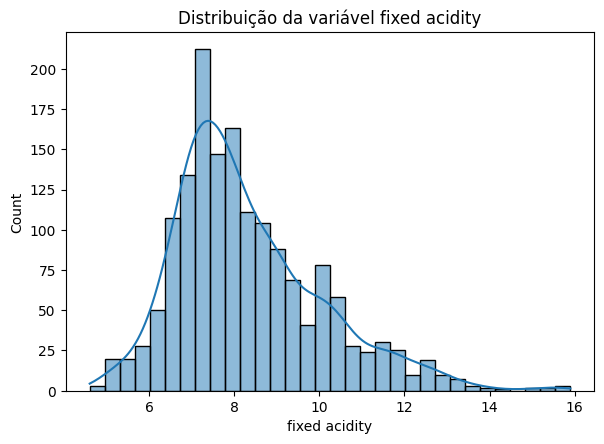

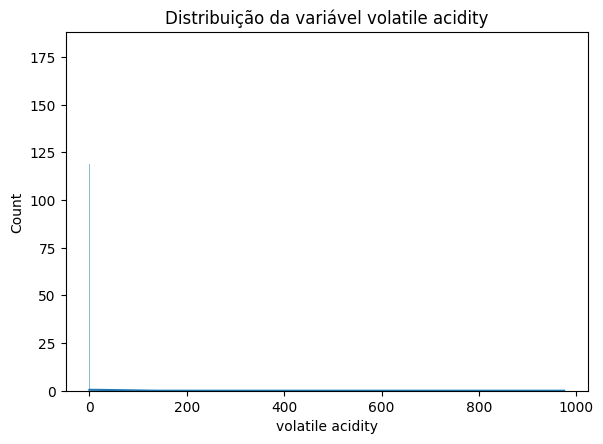

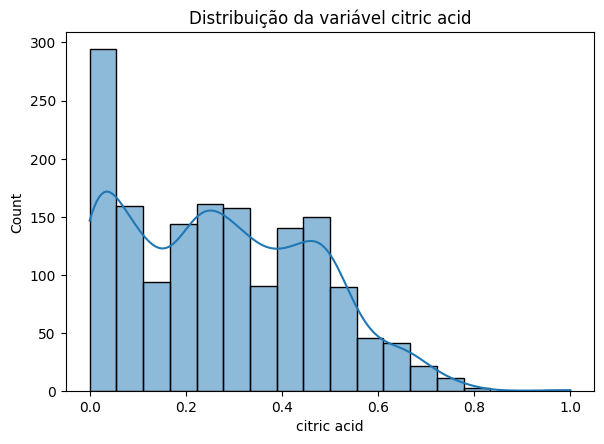

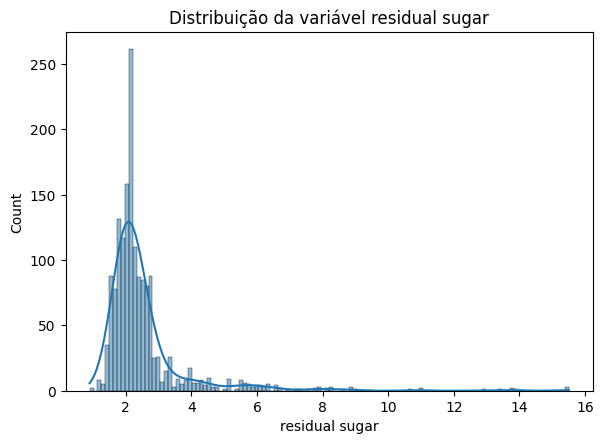

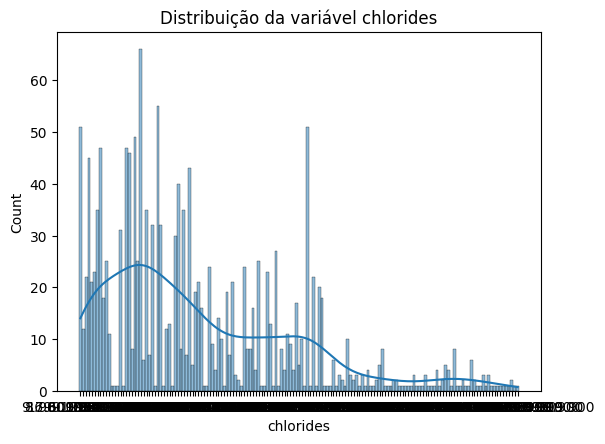

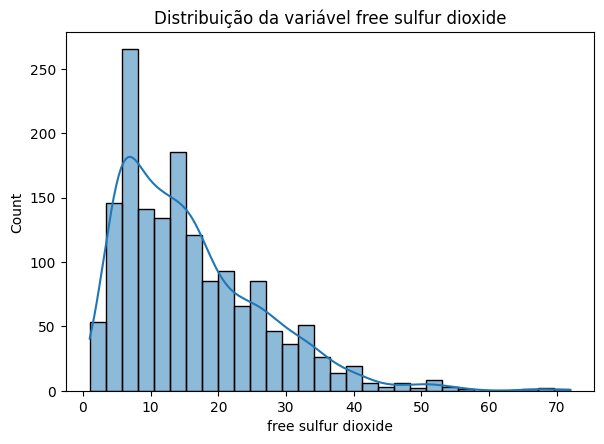

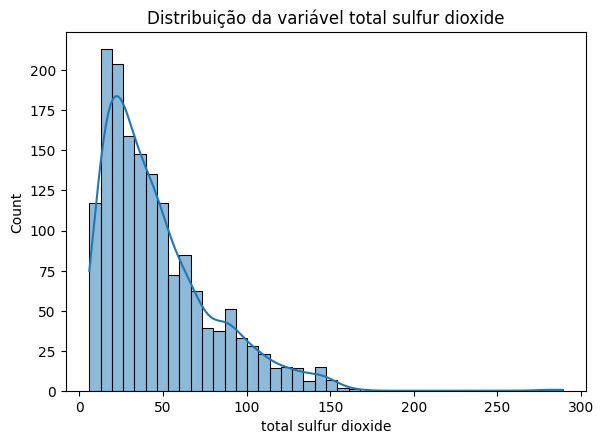

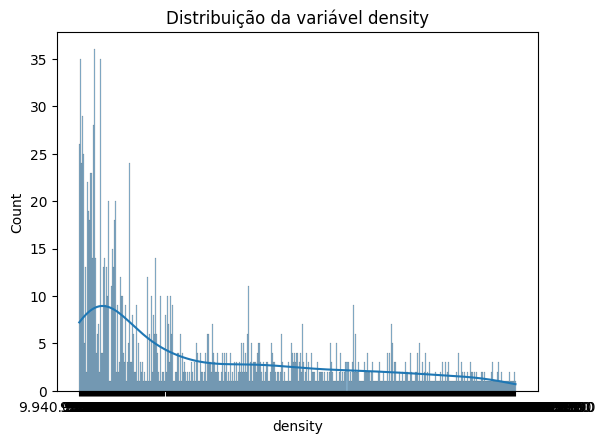

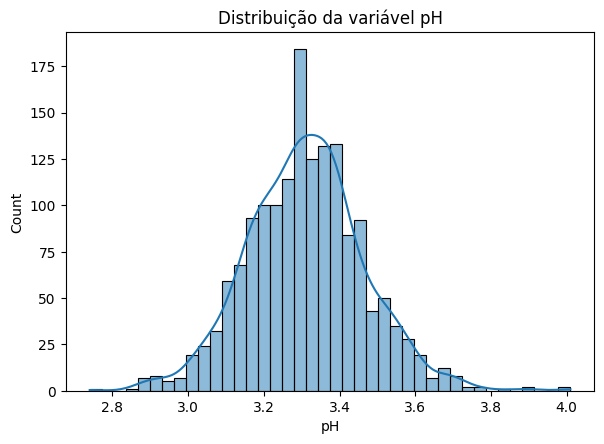

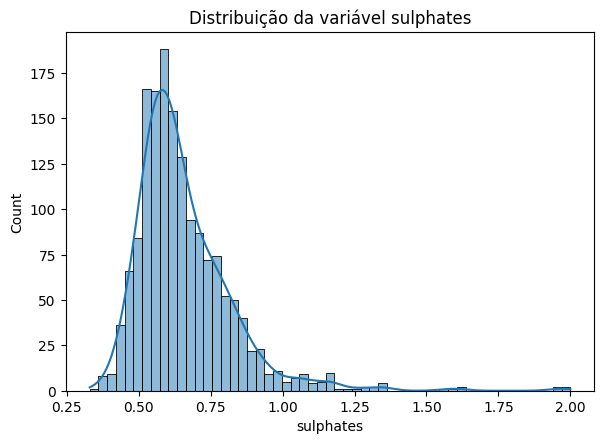

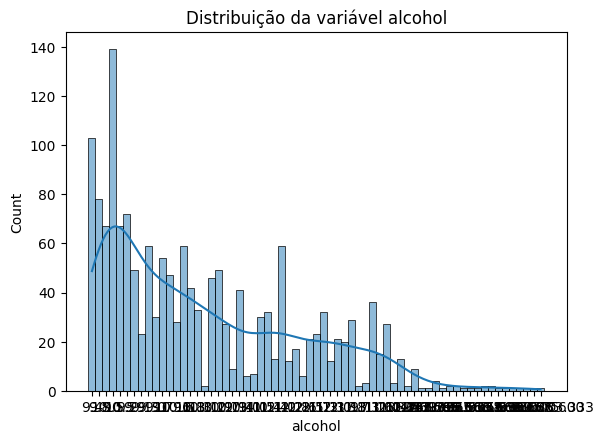

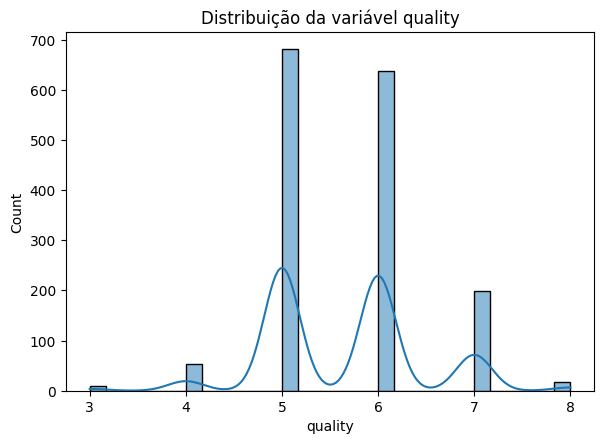

In [ ]:
for col in df:
    sns.histplot(data=df, x=col, kde=True).set_title(f"Distribuição da variável {col}")
    plt.tight_layout(pad=2)  # aumenta o espaçamento
    plt.show()


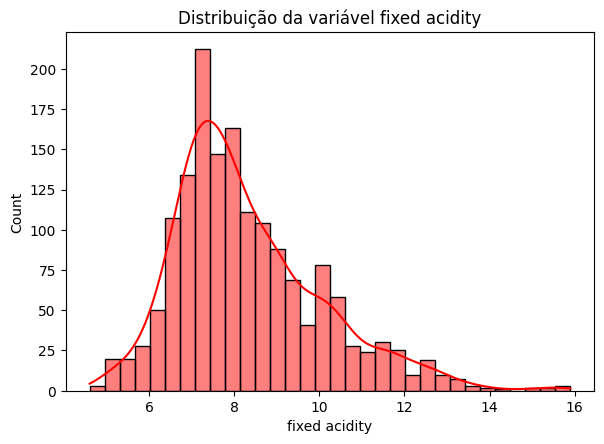

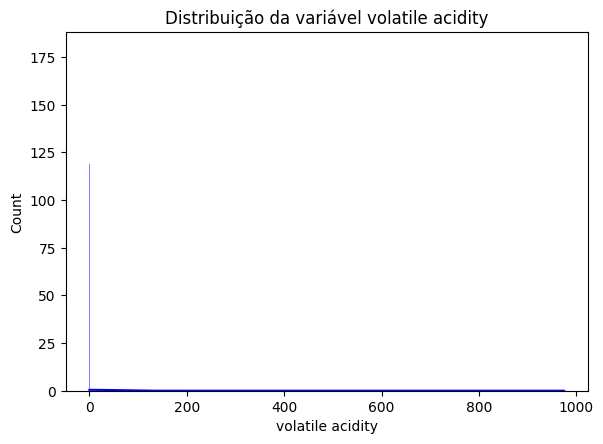

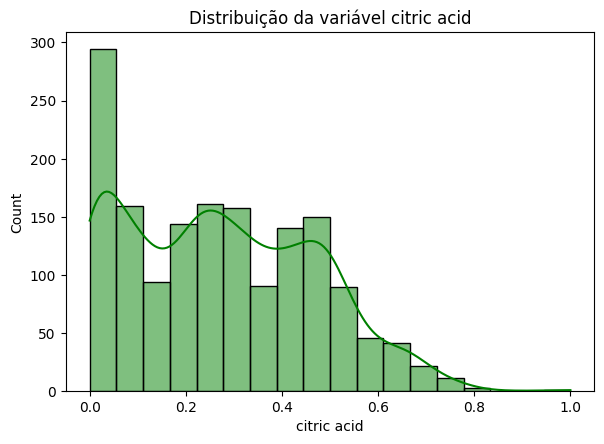

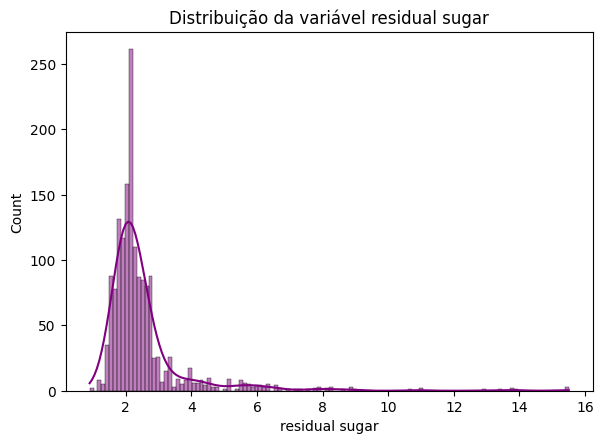

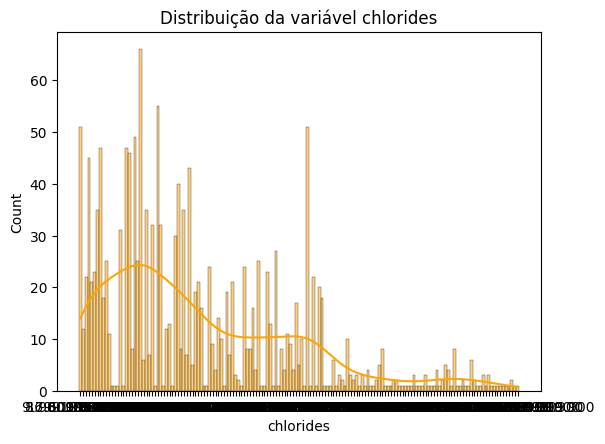

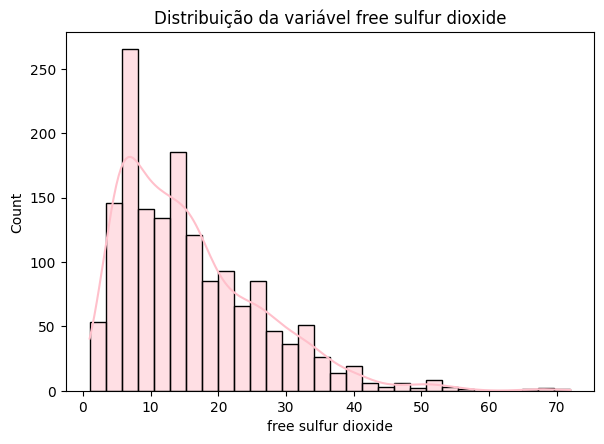

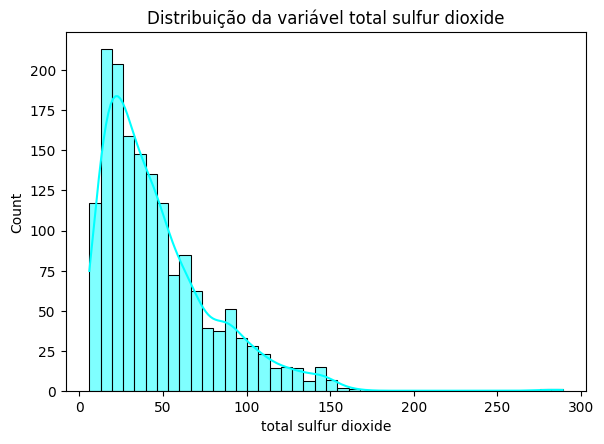

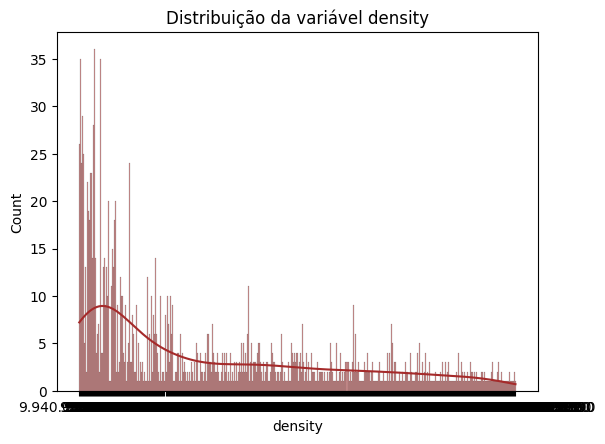

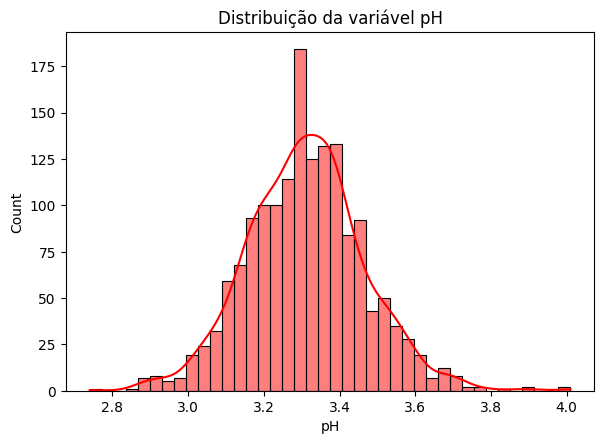

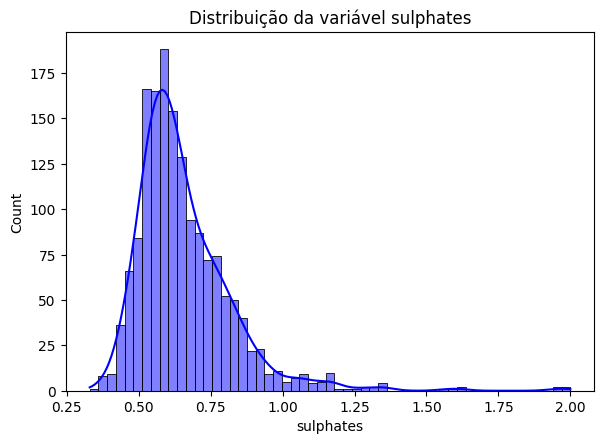

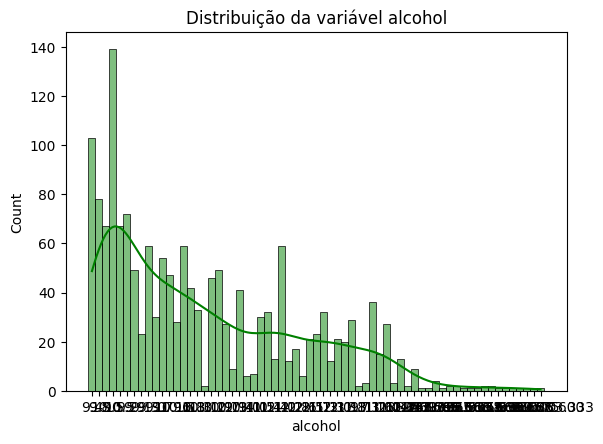

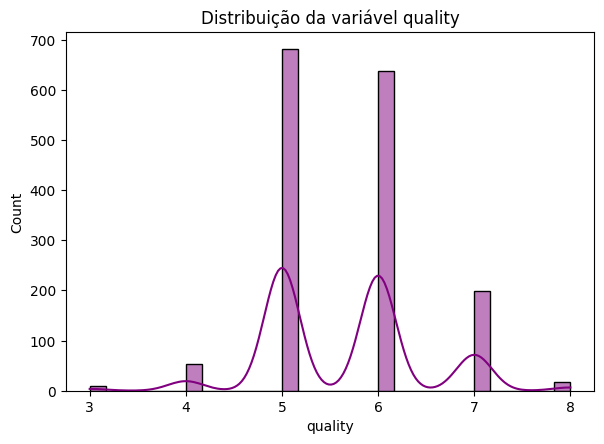

In [ ]:
colors = ['red', 'blue', 'green', 'purple', 'orange', 'pink', 'cyan', 'brown'] # declarar variavel colorsa  1 CBDFHY7

for i, col in enumerate(df): # para todas as colunas
    #plt.figure(figsize=(7,4)) tamanho
    sns.histplot(data=df, x=col, kde=True, color=colors[i % len(colors)])
    plt.title(f"Distribuição da variável {col}")
    plt.tight_layout(pad=2)
    plt.show()


In [ ]:
## Método do Quartil.

#for col in df.drop(columns='quality'):
for col in df.select_dtypes(include='number').drop(columns='quality'):


    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    aux_outliers = df[(df[col] < Q1-(IQR*1.5))
                   | (df[col] > Q3+(IQR*1.5))]

    indices_outliers = aux_outliers.index.tolist()

    if len(indices_outliers) >= 1:

        print(f"A coluna {col} tem {len(indices_outliers)} outliers!")
        print("\nOs índices deles são:\n")
        print(indices_outliers)

    else:

        print(f"Acoluna {col} não tem outliers!")

    print()
    print("="*80)
    print()

A coluna fixed acidity tem 49 outliers!

Os índices deles são:

[205, 206, 243, 244, 264, 294, 328, 338, 339, 347, 353, 359, 363, 364, 366, 374, 381, 391, 394, 409, 429, 440, 442, 446, 470, 472, 509, 510, 516, 538, 544, 548, 554, 555, 557, 559, 560, 564, 565, 596, 599, 601, 603, 611, 652, 680, 811, 814, 1224]


A coluna volatile acidity tem 196 outliers!

Os índices deles são:

[12, 29, 30, 31, 32, 33, 35, 38, 46, 63, 64, 65, 67, 69, 73, 77, 79, 96, 99, 102, 103, 105, 109, 120, 122, 126, 127, 130, 135, 136, 137, 140, 141, 169, 170, 178, 187, 198, 199, 211, 214, 216, 217, 223, 224, 237, 240, 253, 257, 261, 270, 273, 275, 302, 335, 345, 346, 349, 351, 352, 364, 366, 367, 370, 378, 381, 391, 393, 396, 399, 400, 412, 415, 442, 445, 461, 464, 479, 487, 490, 515, 519, 526, 537, 542, 554, 555, 557, 595, 598, 600, 602, 614, 629, 633, 637, 638, 647, 672, 690, 698, 704, 708, 711, 724, 729, 731, 732, 735, 736, 742, 761, 763, 771, 776, 777, 802, 818, 820, 830, 834, 835, 843, 855, 865, 870, 877, 88

# Estudo da variável resposta
Estude os dados na coluna quality, que é a variável resposta do problema. Em particular, responda:
Essa é uma variável contínua ou discreta?
Como as notas estão distribuídas? Quais as notas mais/menos comuns?
Faz sentido discretizar esta variável em dois níveis categóricos?
Se sim, qual seria o valor de corte, e, com este corte, qual é o significado de cada nível categórico?
Como estes dois níveis categóricos estão distribuídos?

In [ ]:
df['quality'].value_counts(normalize=True)

,proportion
quality,
5,0.425891
6,0.398999
7,0.124453
4,0.033146
8,0.011257
3,0.006254


,quality
count,1599.000000
mean,5.636023
std,0.807569
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


<Axes: xlabel='quality', ylabel='Count'>

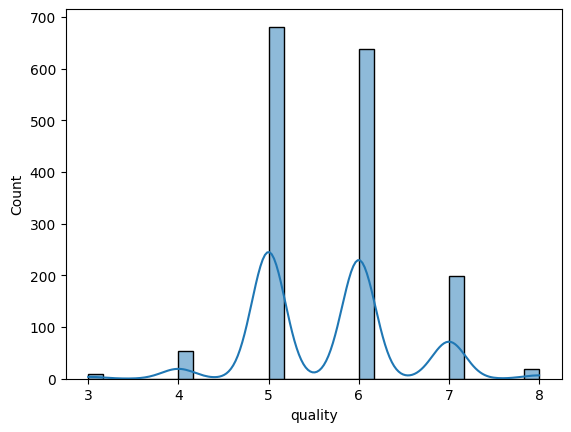

In [ ]:
display(df['quality'].describe())

sns.histplot(data=df, x='quality', kde=True)



# Vamos buscar a correlação das variáveis descritivas com a variável resposta para buscar algumas que pareçam influenciar mais



In [ ]:
for col in ['chlorides','density','alcohol']:  #tranformar todas as colunas object
    df[col] = df[col].str.replace(',', '.').str.replace(' ', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.067844,0.671703,0.114777,0.080543,-0.153794,-0.113181,-0.030758,-0.682978,0.183006,-0.058633,0.124052
volatile acidity,-0.067844,1.000000,-0.200808,0.026036,0.031484,-0.055103,-0.006412,-0.020896,0.051649,-0.075237,-0.079100,-0.141876
citric acid,0.671703,-0.200808,1.000000,0.143577,0.153107,-0.060978,0.035533,-0.010319,-0.541904,0.312770,0.112309,0.226373
residual sugar,0.114777,0.026036,0.143577,1.000000,0.059260,0.187049,0.203028,-0.049295,-0.085652,0.005527,0.044204,0.013732
chlorides,0.080543,0.031484,0.153107,0.059260,1.000000,-0.037502,-0.029459,0.032798,-0.178387,0.220976,-0.163576,-0.054921
free sulfur dioxide,-0.153794,-0.055103,-0.060978,0.187049,-0.037502,1.000000,0.667666,-0.002862,0.070377,0.051658,-0.070586,-0.050656
total sulfur dioxide,-0.113181,-0.006412,0.035533,0.203028,-0.029459,0.667666,1.000000,-0.010926,-0.066495,0.042947,-0.208832,-0.185100
density,-0.030758,-0.020896,-0.010319,-0.049295,0.032798,-0.002862,-0.010926,1.000000,0.023238,-0.034118,0.004382,-0.031075
pH,-0.682978,0.051649,-0.541904,-0.085652,-0.178387,0.070377,-0.066495,0.023238,1.000000,-0.196648,0.204016,-0.057731
sulphates,0.183006,-0.075237,0.312770,0.005527,0.220976,0.051658,0.042947,-0.034118,-0.196648,1.000000,0.091346,0.251397


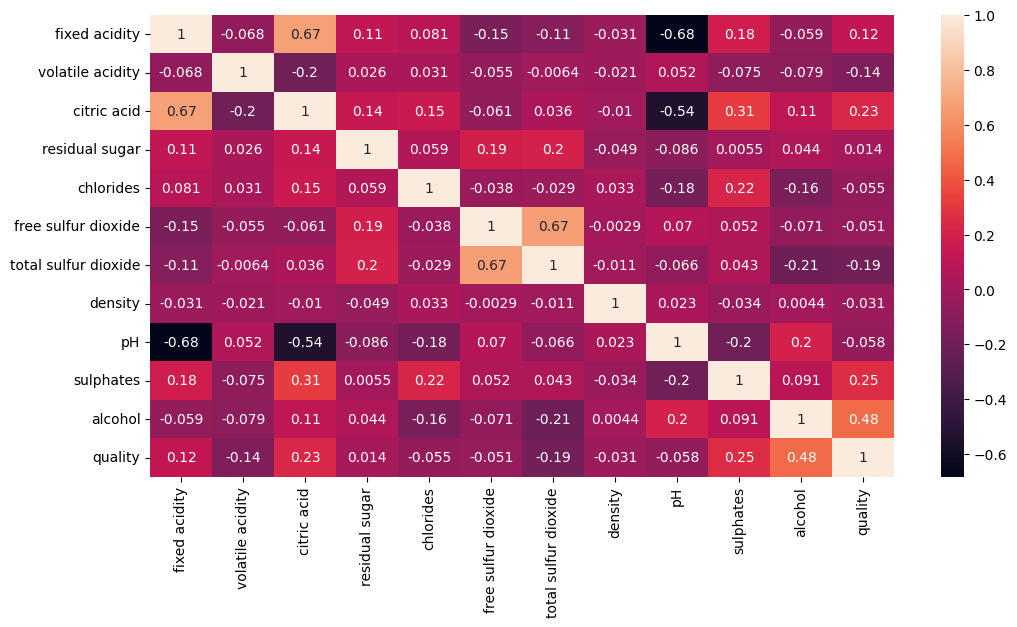

In [ ]:
plt.figure(figsize=(12, 6)) # matriz de correlação analisa o quanto duas variáveis estão relacionadas

sns.heatmap(df.corr(), annot=True);

In [ ]:
df.corr()['quality'].sort_values()

,quality
total sulfur dioxide,-0.185100
volatile acidity,-0.141876
pH,-0.057731
chlorides,-0.054921
free sulfur dioxide,-0.050656
density,-0.031075
residual sugar,0.013732
fixed acidity,0.124052
citric acid,0.226373
sulphates,0.251397


## calcule e/ou visualize (em um gráfico de barras, ou como preferir) o intervalo de confiança de 90% para a média de cada uma das variáveis físico-químicas, agrupadas pelos níveis categóricos da variável resposta quality. Que conclusões são possíveis tirar destes gráficos?

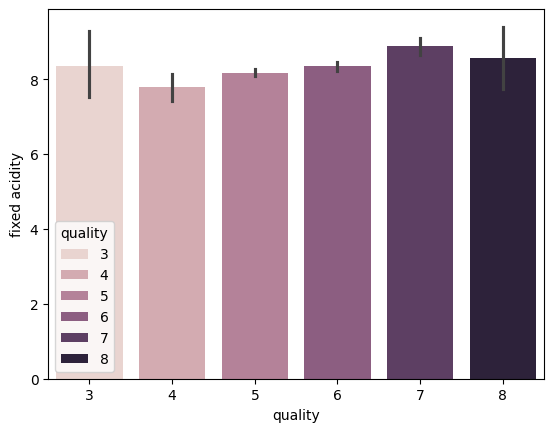

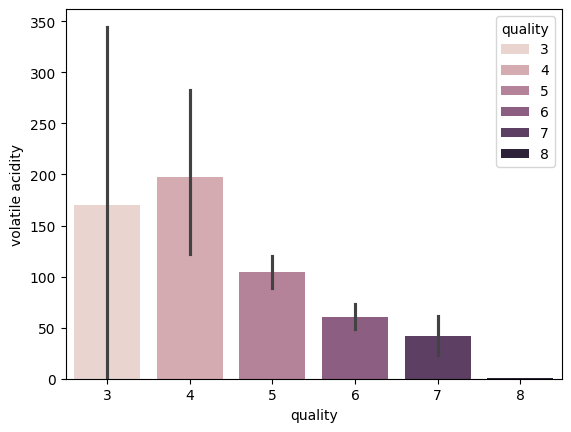

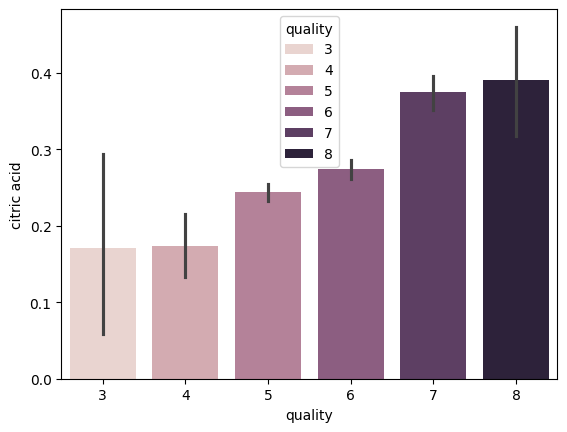

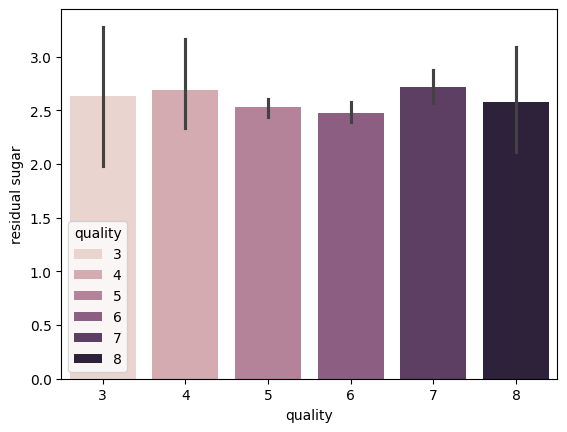

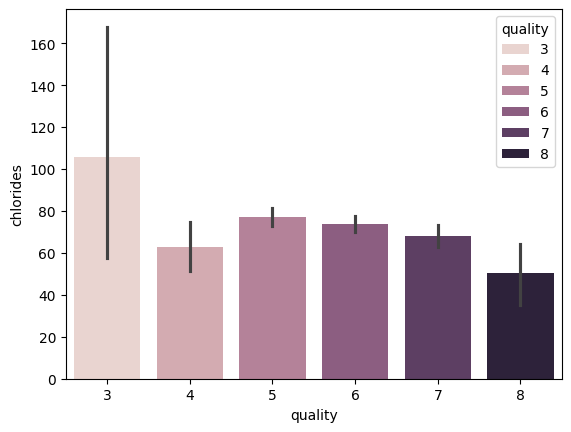

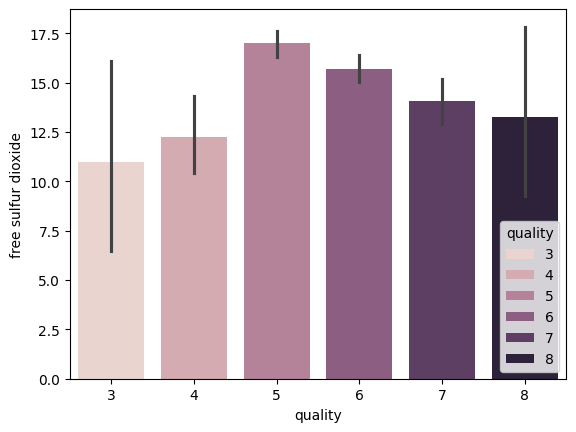

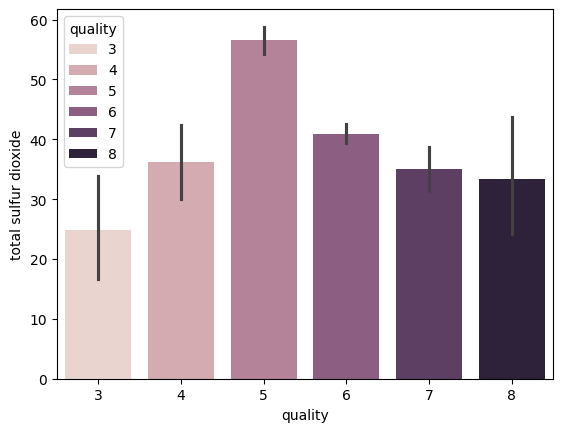

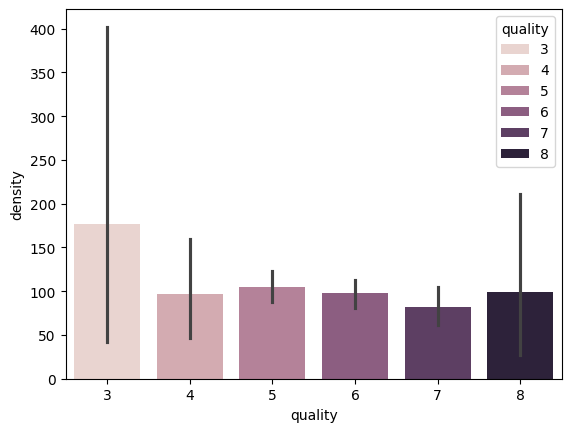

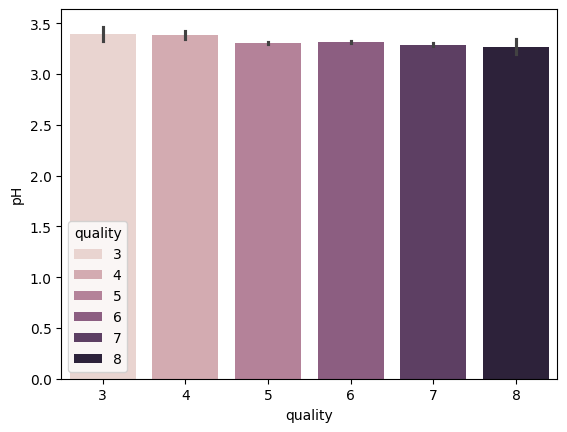

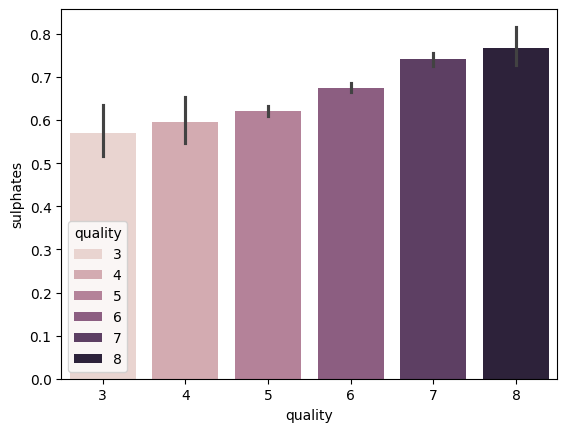

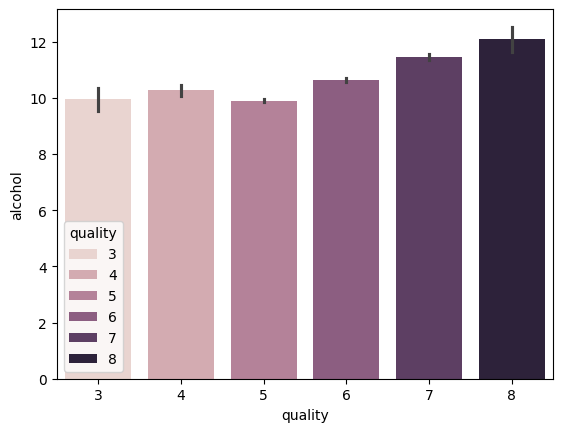

In [ ]:
for col in df.drop(columns='quality'):

    sns.barplot(data=df, x='quality', y=col, errorbar=('ci', 90), hue='quality')
    plt.show()

In [ ]:
df['quality_bin'] = df['quality'].apply(lambda x : "bom" if x > 5 else "ruim")

In [ ]:
df_bin = df.drop(columns=['quality'])
df_bin

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_bin
0,7.4,0.70,0.00,1.9,76.00,11.0,34.0,9.978,3.51,0.56,9.4,ruim
1,7.8,0.88,0.00,2.6,98.00,25.0,67.0,9.968,3.20,0.68,9.8,ruim
2,7.8,0.76,0.04,2.3,92.00,15.0,54.0,997.000,3.26,0.65,9.8,ruim
3,11.2,0.28,0.56,1.9,75.00,17.0,60.0,998.000,3.16,0.58,9.8,bom
4,7.4,0.70,0.00,1.9,76.00,11.0,34.0,9.978,3.51,0.56,9.4,ruim
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.60,0.08,2.0,0.09,32.0,44.0,9.949,3.45,0.58,10.5,ruim
1595,5.9,0.55,0.10,2.2,62.00,39.0,51.0,NaN,3.52,0.76,11.2,bom
1596,6.3,0.51,0.13,2.3,76.00,29.0,40.0,99.574,3.42,0.75,11.0,bom
1597,5.9,645.00,0.12,2.0,75.00,32.0,44.0,NaN,3.57,0.71,10.2,ruim


In [ ]:
df_bin.to_csv('winequality-red-binary.csv', index=False)

In [ ]:
df_bin

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_bin
0,7.4,0.70,0.00,1.9,76.00,11.0,34.0,9.978,3.51,0.56,9.4,ruim
1,7.8,0.88,0.00,2.6,98.00,25.0,67.0,9.968,3.20,0.68,9.8,ruim
2,7.8,0.76,0.04,2.3,92.00,15.0,54.0,997.000,3.26,0.65,9.8,ruim
3,11.2,0.28,0.56,1.9,75.00,17.0,60.0,998.000,3.16,0.58,9.8,bom
4,7.4,0.70,0.00,1.9,76.00,11.0,34.0,9.978,3.51,0.56,9.4,ruim
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.60,0.08,2.0,0.09,32.0,44.0,9.949,3.45,0.58,10.5,ruim
1595,5.9,0.55,0.10,2.2,62.00,39.0,51.0,NaN,3.52,0.76,11.2,bom
1596,6.3,0.51,0.13,2.3,76.00,29.0,40.0,99.574,3.42,0.75,11.0,bom
1597,5.9,645.00,0.12,2.0,75.00,32.0,44.0,NaN,3.57,0.71,10.2,ruim


In [ ]:
df_bin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1232 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1261 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1593 non-null   float64
 11  quality_bin           1599 non-null   object 
dtypes: float64(11), object(1)
memory usage: 150.0+ KB


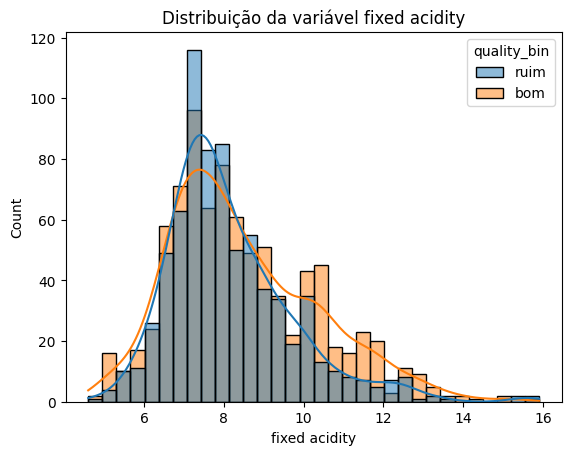

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


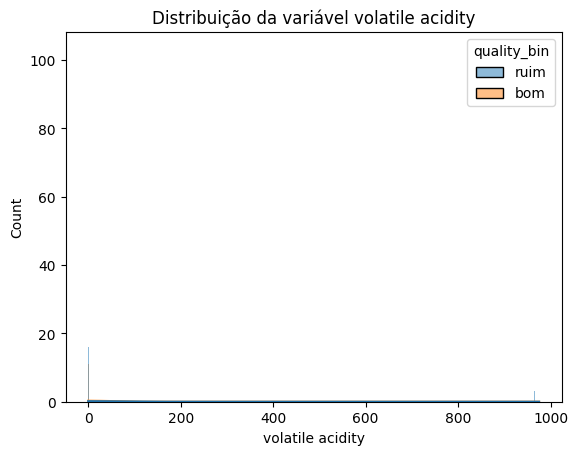

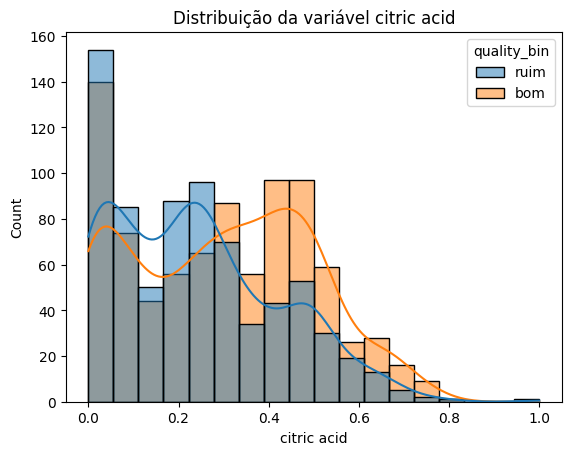

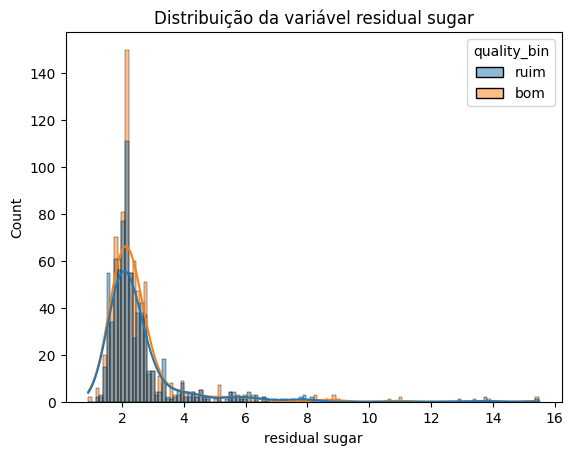

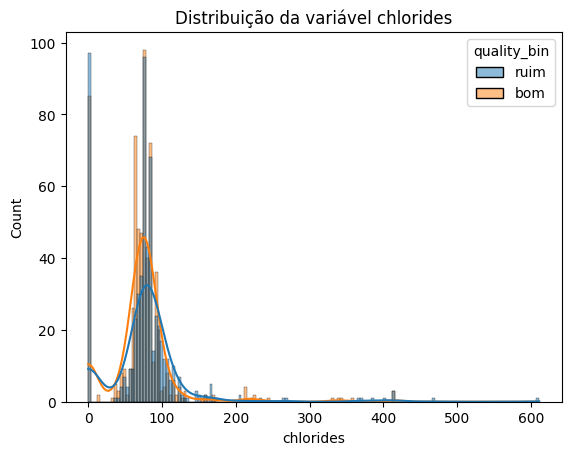

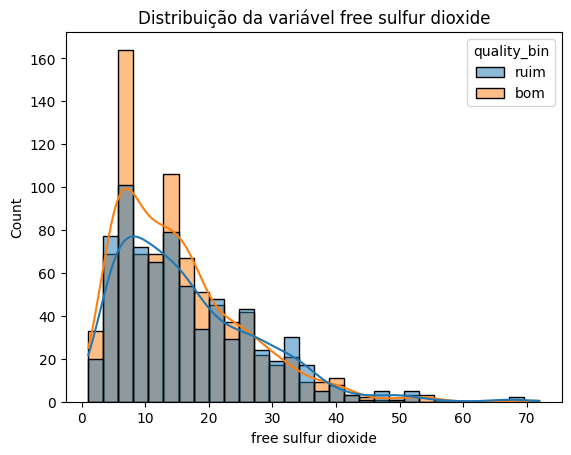

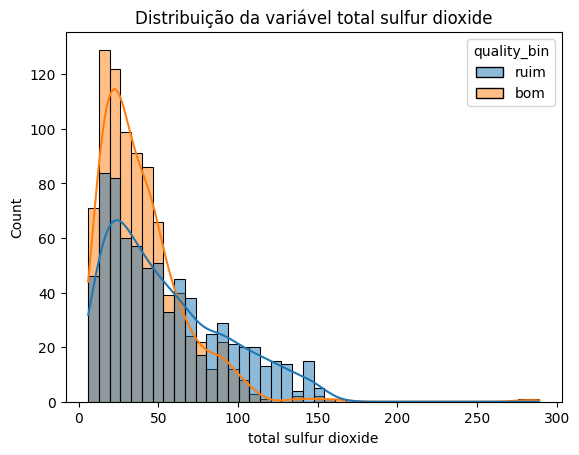

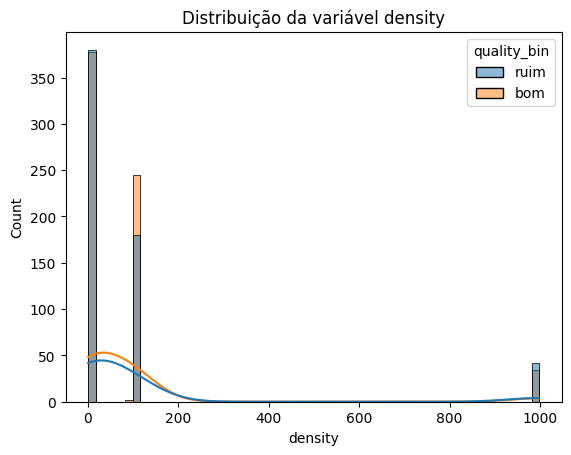

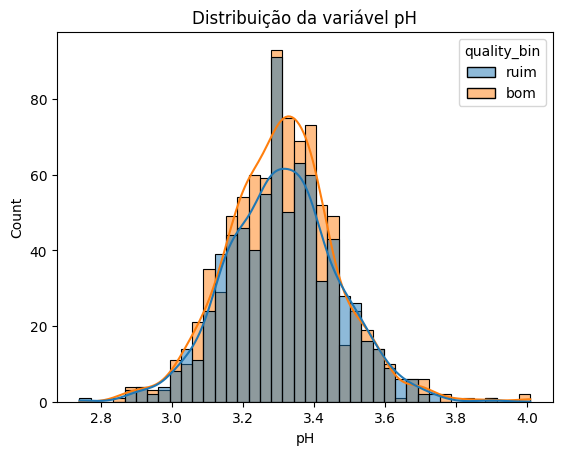

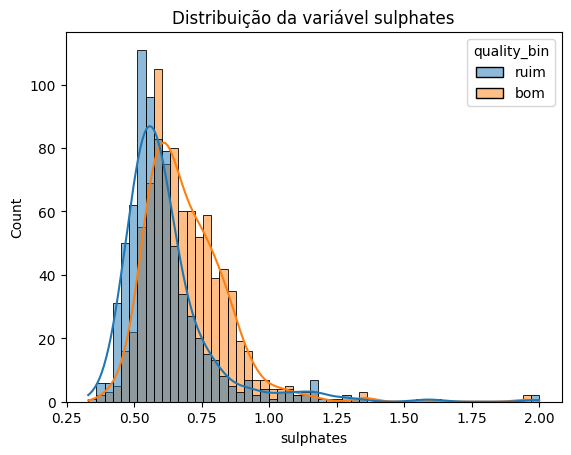

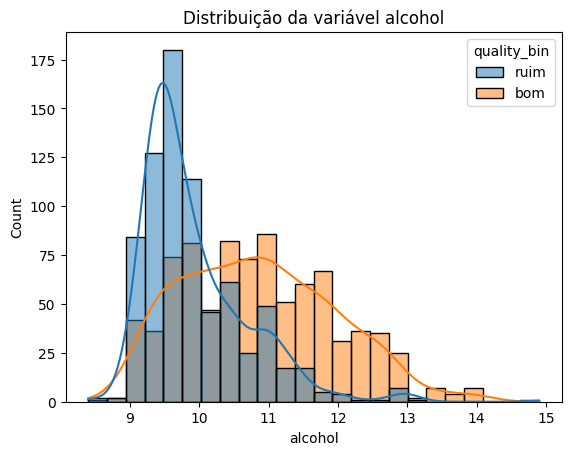

In [ ]:
for col in df_bin.drop(columns='quality_bin'):
    sns.histplot(data=df_bin, x=col, kde=True, hue=df_bin['quality_bin']).set_title(f"Distribuição da variável {col}")
    plt.show()

In [ ]:
X = df.drop('quality', axis=1)
y = df['quality']


In [ ]:
X = df.drop('quality_bin', axis=1)
y = df['quality_bin']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier# este modelo aceita texto como saida

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    random_state=42
)



In [ ]:
from sklearn.preprocessing import LabelEncoder  # nenhum modelo treina com  texto precisa importar e preparar o label encoder (ferramenta que tranforma valores em texto em números)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
X_train.select_dtypes(include='object').columns


Index([], dtype='object')

In [ ]:
rf.fit(X_train, y_train_enc)


RandomForestClassifier(max_depth=14, n_estimators=300, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    random_state=42
)

rf.fit(X_train, y_train_enc)


RandomForestClassifier(max_depth=14, n_estimators=300, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split #dividindo treino e test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=14, n_estimators=300, random_state=42)

In [ ]:
y_pred = rf.predict(X_test) #fazer previsao


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # avaliar o modelo

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

         bom       1.00      1.00      1.00       257
        ruim       1.00      1.00      1.00       223

    accuracy                           1.00       480
   macro avg       1.00      1.00      1.00       480
weighted avg       1.00      1.00      1.00       480

[[257   0]
 [  0 223]]


In [ ]:
train_pred = rf.predict(X_train)

from sklearn.metrics import accuracy_score

print("Accuracy treino:", accuracy_score(y_train, train_pred))


Accuracy treino: 1.0


In [ ]:
import pandas as pd

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances)


                 feature  importance
11               quality    0.749271
10               alcohol    0.083333
9              sulphates    0.042513
1       volatile acidity    0.029290
6   total sulfur dioxide    0.026711
2            citric acid    0.013349
0          fixed acidity    0.011252
7                density    0.011217
4              chlorides    0.009432
8                     pH    0.009246
3         residual sugar    0.007398
5    free sulfur dioxide    0.006986


In [ ]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(rf, X, y, cv=5)

print(cv)
print("CV mean:", cv.mean())


[1. 1. 1. 1. 1.]
CV mean: 1.0


# Analisando para empresa

In [ ]:
importances = pd.DataFrame({       #verificando as variáveis importantes
    'Variável': X.columns,
    'Importância': rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

importances


,Variável,Importância
11,quality,0.749271
10,alcohol,0.083333
9,sulphates,0.042513
1,volatile acidity,0.029290
6,total sulfur dioxide,0.026711
2,citric acid,0.013349
0,fixed acidity,0.011252
7,density,0.011217
4,chlorides,0.009432
8,pH,0.009246


In [ ]:
df.groupby('quality_bin')['alcohol'].describe()


,count,mean,std,min,25%,50%,75%,max
quality_bin,,,,,,,,
bom,849.0,10.856949,1.103067,8.4,10.0,10.8,11.7,14.0
ruim,744.0,9.926478,0.758007,8.4,9.4,9.7,10.3,14.9


## Criar uma tabela CTQ contro de qualidade

In [ ]:
import pandas as pd

# Escolha das variáveis CTQ baseadas no dataset
ctq_data = {
    'CTQ': [
        'Qualidade Final (bom/ruim)',
        'Teor Alcoólico (alcohol)',
        'Sulfatos (sulphates)',
        'pH'
    ],
    'Categoria': [
        'Performance',
        'Variável Crítica',
        'Variável Crítica',
        'Variável de Processo'
    ],
    'Como medir': [
        'Percentual de classificação correta',
        'Média e desvio padrão',
        'Média e desvio padrão',
        'Faixa ideal de pH'
    ],
    'Especificação': [
        'Produto final classificado como BOM',
        'Faixa ideal definida',
        'Faixa ideal definida',
        'Entre 3.0 e 3.5'
    ],
    'Meta': [
        '≥ 90%',
        'Dentro da faixa',
        'Dentro da faixa',
        'Dentro da faixa'
    ],
    'Resultado Atual': [
        df['quality_bin'].value_counts(normalize=True).max() * 100,
        df['alcohol'].mean(),
        df['sulphates'].mean(),
        df['pH'].mean()
    ],
    'Gap': [
        '0%' if df['quality_bin'].value_counts(normalize=True).max() * 100 >= 90 else 'Existe gap',
        'OK' if df['alcohol'].mean() else 'Analisar',
        'OK' if df['sulphates'].mean() else 'Analisar',
        'OK' if 3 <= df['pH'].mean() <= 3.5 else 'Fora da faixa'
    ],
    'Ação': [
        'Implantar classificação automática',
        'Ajuste de processo',
        'Monitoramento',
        'Controle estatístico'
    ]
}

ctq_table = pd.DataFrame(ctq_data)
ctq_table


,CTQ,Categoria,Como medir,Especificação,Meta,Resultado Atual,Gap,Ação
0,Qualidade Final (bom/ruim),Performance,Percentual de classificação correta,Produto final classificado como BOM,≥ 90%,53.470919,Existe gap,Implantar classificação automática
1,Teor Alcoólico (alcohol),Variável Crítica,Média e desvio padrão,Faixa ideal definida,Dentro da faixa,10.422379,OK,Ajuste de processo
2,Sulfatos (sulphates),Variável Crítica,Média e desvio padrão,Faixa ideal definida,Dentro da faixa,0.658149,OK,Monitoramento
3,pH,Variável de Processo,Faixa ideal de pH,Entre 3.0 e 3.5,Dentro da faixa,3.311113,OK,Controle estatístico


# Tabela que calcula GAP automatizado

In [ ]:
resultado_atual = df['quality_bin'].value_counts(normalize=True).max() * 100
gap_real = 90 - resultado_atual

ctq_data = {
    'CTQ': ['Qualidade Final (bom/ruim)'],
    'Resultado Atual (%)': [resultado_atual],
    'Meta (%)': [90],
    'Gap (%)': [gap_real]
}

pd.DataFrame(ctq_data)


,CTQ,Resultado Atual (%),Meta (%),Gap (%)
0,Qualidade Final (bom/ruim),53.470919,90,36.529081


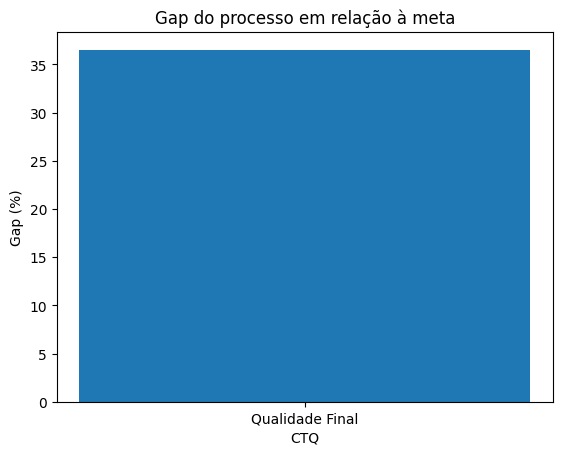

In [ ]:
import matplotlib.pyplot as plt

plt.bar(ctq_df['CTQ'], ctq_df['Gap'])
plt.title('Gap do processo em relação à meta')
plt.ylabel('Gap (%)')
plt.xlabel('CTQ')
plt.show()


=== DASHBOARD DE QUALIDADE ===


,Indicador,Resultado Atual (%),Meta (%),Gap (%)
0,Qualidade Final,53.470919,90,36.529081


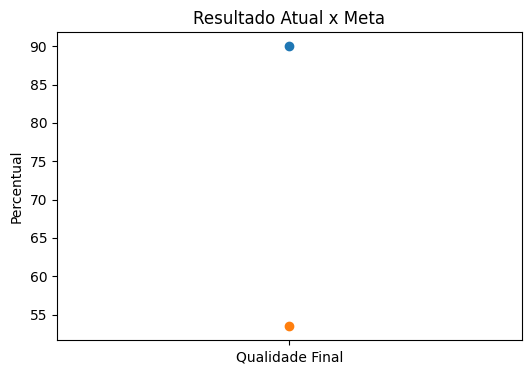

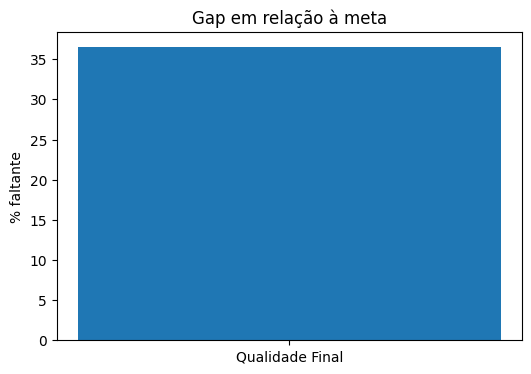

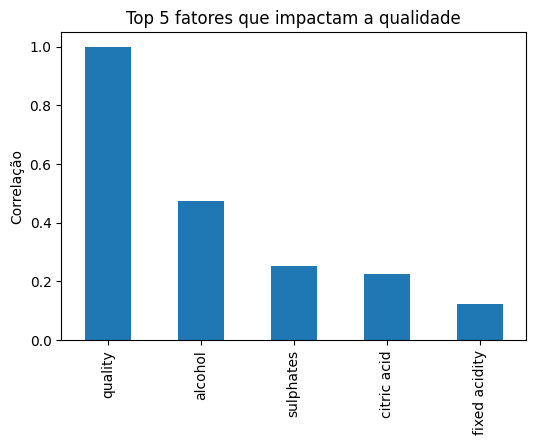


ANÁLISE:
- A meta é atingir 90% de produtos classificados como BOM.
- O processo atual está em 53.47%.
- O gap para atingir a meta é de 36.53%.

RECOMENDAÇÕES:
- Ajustar variáveis críticas com maior correlação com qualidade.
- Aplicar controle estatístico (CEP) no processo.
- Criar plano de ação para redução do gap.
- Utilizar o modelo para prever a qualidade antes do produto finalizar.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1. CÁLCULO DOS INDICADORES
# ================================
resultado_atual = df['quality_bin'].value_counts(normalize=True).max() * 100
meta = 90
gap = meta - resultado_atual

ctq = pd.DataFrame({
    'Indicador':['Qualidade Final'],
    'Resultado Atual (%)':[resultado_atual],
    'Meta (%)':[meta],
    'Gap (%)':[gap]
})

# ================================
# 2. TABELA PRINCIPAL
# ================================
print("=== DASHBOARD DE QUALIDADE ===")
display(ctq)

# ================================
# 3. GRÁFICO META X REAL
# ================================
plt.figure(figsize=(6,4))
plt.plot(ctq['Indicador'], ctq['Meta (%)'], marker='o')
plt.plot(ctq['Indicador'], ctq['Resultado Atual (%)'], marker='o')
plt.title("Resultado Atual x Meta")
plt.ylabel("Percentual")
plt.show()

# ================================
# 4. GRÁFICO DO GAP
# ================================
plt.figure(figsize=(6,4))
plt.bar(ctq['Indicador'], ctq['Gap (%)'])
plt.title('Gap em relação à meta')
plt.ylabel('% faltante')
plt.show()

# ================================
# 5. VARIÁVEIS CRÍTICAS DO PROCESSO
# (mostra onde atacar primeiro)
# ================================
import seaborn as sns
corr = df.corr(numeric_only=True)['quality'].sort_values(ascending=False)

plt.figure(figsize=(6,4))
corr.head(5).plot(kind='bar')
plt.title("Top 5 fatores que impactam a qualidade")
plt.ylabel("Correlação")
plt.show()

# ================================
# 6. EXPLICAÇÃO PRONTA PARA SLIDE
# ================================
print("\nANÁLISE:")
print(f"- A meta é atingir 90% de produtos classificados como BOM.")
print(f"- O processo atual está em {resultado_atual:.2f}%.")
print(f"- O gap para atingir a meta é de {gap:.2f}%.")
print("\nRECOMENDAÇÕES:")
print("- Ajustar variáveis críticas com maior correlação com qualidade.")
print("- Aplicar controle estatístico (CEP) no processo.")
print("- Criar plano de ação para redução do gap.")
print("- Utilizar o modelo para prever a qualidade antes do produto finalizar.")


# Insights
Ajustar variáveis críticas com maior correlação com qualidade

(Objetivo: reduzir o Gap atuando no que realmente importa)

Por quê: O RandomForest e a correlação indicam quais variáveis influenciam mais a qualidade. Ações sobre essas variáveis têm maior ROI.

In [ ]:
import pandas as pd
importances = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
corr = df.corr(numeric_only=True)['quality'].abs().sort_values(ascending=False)
print(importances.head(8))
print(corr.head(8))


                 feature  importance
11               quality    0.749271
10               alcohol    0.083333
9              sulphates    0.042513
1       volatile acidity    0.029290
6   total sulfur dioxide    0.026711
2            citric acid    0.013349
0          fixed acidity    0.011252
7                density    0.011217
quality                 1.000000
alcohol                 0.475875
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide    0.185100
volatile acidity        0.141876
fixed acidity           0.124052
pH                      0.057731
Name: quality, dtype: float64
